# ICU Multimodal Encoders — Text (ClinicalBERT) + Image (DenseNet-121)
> **Text source** : MIMIC-IV-Note `mimiciv_note.discharge` + `radiology` via `pandas_gbq`  
> **Image source** : MIMIC-CXR-JPG v2.0.0 via PhysioNet wget (no BQ dependency)  
> **Text output** : 768-dim ClinicalBERT embeddings per stay  
> **Image output** : 1024-dim DenseNet features + 14 CheXpert label probs per stay  
> **Leakage policy** : only notes/CXR from within ICU window; same train/val/test split as encoder notebook  
> **Auth** : pandas_gbq for notes (mimiciv_note access confirmed) | wget + PhysioNet creds for CXR files

## Step 0 — Install Dependencies

In [5]:
import subprocess, sys

# Step 1: Restore Pillow to the system version (11.3.0) — don't fight it
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                '--force-reinstall', 'Pillow==11.3.0'],
               capture_output=True)

# Step 2: Install everything else (no Pillow upgrade allowed)
PACKAGES = [
    'torch', 'torchvision', 'transformers',
    'google-cloud-bigquery', 'google-cloud-storage',
    'db-dtypes', 'umap-learn', 'tqdm',
]
for pkg in PACKAGES:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    print(f'  [{"OK" if r.returncode==0 else "FAIL"}] {pkg}')

# Step 3: Install torchxrayvision from source (latest main has Pillow 11 fix)
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'git+https://github.com/mlmed/torchxrayvision.git'],
    capture_output=True, text=True
)
print(f'  [{"OK" if r.returncode==0 else "FAIL"}] torchxrayvision (from source)')
if r.returncode != 0:
    print(r.stderr[-500:])

# Step 4: Patch the broken _typing.py in place so _Ink exists
patch = """
from typing import Union, Tuple
# Pillow 11.x compatibility patch
try:
    from ._typing import _Ink
except ImportError:
    _Ink = Union[
        Tuple[int, int, int, int],
        Tuple[int, int, int],
        Tuple[int, int],
        int,
        float,
        str,
    ]
"""
import pathlib, PIL
typing_file = pathlib.Path(PIL.__file__).parent / '_typing.py'
content = typing_file.read_text()
if '_Ink' not in content:
    with open(typing_file, 'a') as f:
        f.write('\n_Ink = Union[int, float, str, tuple]\n')
    print('✅ Patched PIL/_typing.py with _Ink')
else:
    print('✅ PIL/_typing.py already has _Ink')

# Step 5: Clear PIL from sys.modules and reimport fresh
import sys
for mod in list(sys.modules.keys()):
    if 'PIL' in mod:
        del sys.modules[mod]

# Step 6: Verify
import PIL, torch, transformers, torchxrayvision as xrv
from PIL import Image
print(f'\nPillow       : {PIL.__version__}')
print(f'PyTorch      : {torch.__version__}')
print(f'Transformers : {transformers.__version__}')
print(f'TXV (CXR)    : {xrv.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device   : {torch.cuda.get_device_name(0)}')
print('✅ All packages ready.')

  [OK] torch
  [OK] torchvision
  [OK] transformers
  [OK] google-cloud-bigquery
  [OK] google-cloud-storage
  [OK] db-dtypes
  [OK] umap-learn
  [OK] tqdm
  [OK] torchxrayvision (from source)
✅ Patched PIL/_typing.py with _Ink

Pillow       : 11.3.0
PyTorch      : 2.10.0+cpu
Transformers : 5.0.0
TXV (CXR)    : 1.4.0
GPU available: False
✅ All packages ready.


## Step 1 — Environment Setup & Paths

In [6]:
import warnings, logging, os
from pathlib import Path
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('ICU_MultiEncoder')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
import pandas_gbq

from google.colab import drive, auth
drive.mount('/content/drive')
auth.authenticate_user()   # authenticates gcloud for BigQuery

# ── GCP project
GCP_PROJECT = 'icuaiassistanttextencoder'   # <-- your confirmed project ID

# ── Local paths
BASE      = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')
CXR_CACHE = Path('/content/cxr_cache')
CXR_CACHE.mkdir(exist_ok=True)

TEXT_EMB_OUT = BASE / 'icu_text_embeddings.parquet'
CXR_EMB_OUT  = BASE / 'icu_cxr_embeddings.parquet'
TEXT_RPT_PNG = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_text_encoder_report.png')
CXR_RPT_PNG  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_cxr_encoder_report.png')

DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
log.info('Device: %s', DEVICE)

# ── Plot theme
DARK_BG='#0F172A'; CARD_BG='#1E293B'; TEXT='#F1F5F9'; GRID='#334155'
PAL={'blue':'#2563EB','teal':'#0891B2','purple':'#7C3AED',
     'green':'#16A34A','orange':'#EA580C','red':'#DC2626','amber':'#CA8A04'}
plt.rcParams.update({
    'figure.facecolor':DARK_BG,'axes.facecolor':CARD_BG,'axes.edgecolor':GRID,
    'axes.labelcolor':TEXT,'axes.titlecolor':TEXT,'xtick.color':TEXT,
    'ytick.color':TEXT,'text.color':TEXT,'grid.color':GRID,'grid.linewidth':0.5,
    'axes.grid':True,'axes.titlesize':12,'axes.labelsize':10,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,
})
log.info('Environment ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1b — PhysioNet Credentials
> Used for wget-based CXR image and metadata downloads.  
> Your account (`gomathimeena`) has confirmed wget access to MIMIC-CXR-JPG.

In [7]:
import getpass

print('Enter your PhysioNet credentials (used for wget CXR downloads):')
PHYSIONET_USER = input('Username: ')
PHYSIONET_PASS = getpass.getpass('Password: ')

# ── Quick verify — wget a tiny file to confirm credentials work
import subprocess, tempfile, os
test_out = '/tmp/pn_test.txt'
r = subprocess.run([
    'wget', '-q', '-O', test_out,
    '--user', PHYSIONET_USER, '--password', PHYSIONET_PASS,
    'https://physionet.org/files/mimic-cxr-jpg/2.0.0/LICENSE.txt'
], capture_output=True, text=True)

if r.returncode == 0 and os.path.getsize(test_out) > 100:
    log.info('PhysioNet wget auth OK ✅')
else:
    raise ValueError(
        'PhysioNet wget auth FAILED.\n'
        'Check username/password at https://physionet.org/login/\n'
        f'wget stderr: {r.stderr}'
    )

Enter your PhysioNet credentials (used for wget CXR downloads):
Username: gomathimeena.m@gmail.com
Password: ··········


## Step 1c — Download CXR Metadata via wget
> Downloads `mimic-cxr-2.0.0-metadata.csv.gz` and `IMAGE_FILENAMES` from PhysioNet.  
> These two files completely replace the forbidden `mimic_cxr.record_list` and  
> `mimic_cxr.dicom_metadata_string` BigQuery tables.

In [8]:
import subprocess, getpass

PHYSIONET_USER     = input('PhysioNet username: ')
PHYSIONET_PASS     = getpass.getpass('PhysioNet password: ')
PHYSIONET_CXR_BASE = 'https://physionet.org/files/mimic-cxr-jpg/2.0.0'

test_files = [
    'IMAGE_FILENAMES',
    'mimic-cxr-2.0.0-split.csv.gz',
    'mimic-cxr-2.0.0-chexpert.csv.gz',
    'mimic-cxr-2.0.0-metadata.csv.gz',
    'mimic-cxr-2.0.0-negbio.csv.gz',
]

print(f'\nProbing {PHYSIONET_CXR_BASE} ...\n')
for fname in test_files:
    url = f'{PHYSIONET_CXR_BASE}/{fname}'
    r   = subprocess.run([
        'wget', '-q', '--spider',
        '--user', PHYSIONET_USER,
        '--password', PHYSIONET_PASS,
        url
    ], capture_output=True, text=True)
    status = '✅ exists' if r.returncode == 0 else '❌ not found'
    print(f'  {status}  {fname}')

PhysioNet username: gomathimeena.m@gmail.com
PhysioNet password: ··········

Probing https://physionet.org/files/mimic-cxr-jpg/2.0.0 ...

  ❌ not found  IMAGE_FILENAMES
  ✅ exists  mimic-cxr-2.0.0-split.csv.gz
  ✅ exists  mimic-cxr-2.0.0-chexpert.csv.gz
  ✅ exists  mimic-cxr-2.0.0-metadata.csv.gz
  ✅ exists  mimic-cxr-2.0.0-negbio.csv.gz


In [9]:
import subprocess, gzip, getpass
from pathlib import Path
import pandas as pd

PHYSIONET_CXR_BASE = 'https://physionet.org/files/mimic-cxr-jpg/2.0.0'
METADATA_CACHE     = Path('/content/mimic_cxr_metadata.csv.gz')
SPLIT_CACHE        = Path('/content/mimic_cxr_split.csv.gz')


def wget_physionet(url: str, out_path: Path, desc: str) -> None:
    if out_path.exists() and out_path.stat().st_size > 1000:
        log.info('Already cached: %s', out_path.name)
        return
    log.info('Downloading %s ...', desc)
    r = subprocess.run([
        'wget', '-q', '-O', str(out_path),
        '--user', PHYSIONET_USER, '--password', PHYSIONET_PASS, url
    ], capture_output=True, text=True)
    if r.returncode != 0 or not out_path.exists() or out_path.stat().st_size < 1000:
        if out_path.exists(): out_path.unlink()
        raise RuntimeError(f'wget failed for {desc}: {r.stderr}')
    log.info('Saved %s: %d MB', out_path.name, out_path.stat().st_size // 1_000_000)


# ── Download metadata + split CSVs
wget_physionet(f'{PHYSIONET_CXR_BASE}/mimic-cxr-2.0.0-metadata.csv.gz',
               METADATA_CACHE, 'CXR metadata CSV')
wget_physionet(f'{PHYSIONET_CXR_BASE}/mimic-cxr-2.0.0-split.csv.gz',
               SPLIT_CACHE, 'CXR split CSV')

# ── Verify metadata is real gzip
with open(METADATA_CACHE, 'rb') as f:
    if f.read(2) != b'\x1f\x8b':
        METADATA_CACHE.unlink()
        raise ValueError('Metadata not gzip — credentials may be wrong')

# ── Load metadata → frontal views only
with gzip.open(METADATA_CACHE, 'rt') as f:
    dicom_meta = pd.read_csv(f, low_memory=False)
log.info('Metadata: %s rows | cols: %s',
         f'{len(dicom_meta):,}', dicom_meta.columns.tolist())

dicom_meta_frontal = dicom_meta[
    dicom_meta['ViewPosition'].isin(['PA', 'AP'])
][['dicom_id', 'ViewPosition', 'StudyDate']].copy()
log.info('Frontal views: %s', f'{len(dicom_meta_frontal):,}')

# ── Load split CSV → has subject_id, study_id, dicom_id
with gzip.open(SPLIT_CACHE, 'rt') as f:
    split_df = pd.read_csv(f)
log.info('Split CSV: %s | cols: %s',
         split_df.shape, split_df.columns.tolist())

# ── Reconstruct file path from subject_id + study_id + dicom_id
# MIMIC-CXR-JPG path format: files/p{first2}/p{subject}/s{study}/{dicom}.jpg
def build_cxr_path(row) -> str:
    subj  = int(row['subject_id'])
    study = int(row['study_id'])
    dicom = str(row['dicom_id'])
    p_grp = f'p{str(subj)[:2]}'   # e.g. p10, p11 ... p19
    return f'files/{p_grp}/p{subj}/s{study}/{dicom}.jpg'

# ── Join split with frontal metadata → gives path + ViewPosition + StudyDate
cxr_records = split_df.merge(
    dicom_meta_frontal, on='dicom_id', how='inner'
)
cxr_records['path'] = cxr_records.apply(build_cxr_path, axis=1)

log.info('Frontal CXR records with paths: %s', f'{len(cxr_records):,}')
log.info('View split:\n%s',
         cxr_records['ViewPosition'].value_counts().to_string())

## Step 2 — Load ICU Stay Cohort & Split Labels

In [10]:
static        = pd.read_parquet(BASE / 'icu_static_features.parquet')
encoder_feats = pd.read_parquet(BASE / 'icu_encoder_features.parquet')

cohort = static[['stay_id','subject_id','hadm_id','intime','outtime']].copy()
cohort['intime']  = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])

split_map = encoder_feats[['stay_id','split']]
cohort    = cohort.merge(split_map, on='stay_id', how='left')
cohort['split'] = cohort['split'].fillna('train')

log.info('Cohort: %d stays | %d unique subjects',
         len(cohort), cohort['subject_id'].nunique())
log.info('Split distribution:\n%s', cohort['split'].value_counts().to_string())

HADM_IDS    = cohort['hadm_id'].dropna().astype(int).unique().tolist()
SUBJECT_IDS = cohort['subject_id'].dropna().astype(int).unique().tolist()
log.info('Unique hadm_ids: %d | subject_ids: %d',
         len(HADM_IDS), len(SUBJECT_IDS))

## Step 6 — Build CXR Metadata from wget Files
> No BigQuery needed. Uses IMAGE_FILENAMES + metadata CSV downloaded in Step 1c.  
> Completely replaces `mimic_cxr.record_list` and `mimic_cxr.dicom_metadata_string`.

In [11]:
# ── Filter image list to cohort subjects
cxr_cohort = cxr_records[
    cxr_records['subject_id'].isin(SUBJECT_IDS)
].copy()
log.info('Frontal CXR records for cohort subjects: %d', len(cxr_cohort))

# ── Parse StudyDate
cxr_cohort['study_dt'] = pd.to_datetime(
    cxr_cohort['StudyDate'], format='%Y%m%d', errors='coerce'
)

# ── Merge with cohort to get stay_id / intime / outtime
cxr_meta = cxr_cohort.merge(
    cohort[['subject_id','stay_id','intime','outtime','split']],
    on='subject_id', how='inner'
)
cxr_meta['intime']       = pd.to_datetime(cxr_meta['intime'])
cxr_meta['window_start'] = cxr_meta['intime'] - pd.Timedelta(hours=48)
cxr_meta['window_end']   = cxr_meta['intime'] + pd.Timedelta(hours=24)

# ── Temporal filter: CXR within admission window
cxr_filtered = cxr_meta[
    (cxr_meta['study_dt'] >= cxr_meta['window_start']) &
    (cxr_meta['study_dt'] <= cxr_meta['window_end'])
].copy()

# ── Most recent CXR per stay
cxr_filtered = (
    cxr_filtered
    .sort_values(['stay_id','study_dt'], ascending=[True, False])
    .drop_duplicates(subset='stay_id', keep='first')
    .reset_index(drop=True)
)

log.info('Stays with valid CXR: %d / %d (%.1f%%)',
         len(cxr_filtered), len(cohort), len(cxr_filtered)/len(cohort)*100)
log.info('View distribution:\n%s',
         cxr_filtered['ViewPosition'].value_counts().to_string())

## Step 7 — DenseNet-121 CXR Encoder
> Images downloaded via PhysioNet wget on demand and cached to Colab disk.  
> Output: 1024-dim feature vector + pathology label probabilities per image.

In [12]:
# ── First check what columns cxr_filtered has
print('cxr_filtered columns:', cxr_filtered.columns.tolist())
print('cxr_records columns: ', cxr_records.columns.tolist())
print('split_df columns:    ', split_df.columns.tolist())

cxr_filtered columns: ['dicom_id', 'study_id', 'subject_id', 'split_x', 'ViewPosition', 'StudyDate', 'path', 'study_dt', 'stay_id', 'intime', 'outtime', 'split_y', 'window_start', 'window_end']
cxr_records columns:  ['dicom_id', 'study_id', 'subject_id', 'split', 'ViewPosition', 'StudyDate', 'path']
split_df columns:     ['dicom_id', 'study_id', 'subject_id', 'split']


In [13]:
# ── Clean up duplicate split columns
# split_x = from split CSV (train/validate/test)
# split_y = from cohort merge
# Use cohort's split (split_y) as it matches your train/val/test labels

cxr_filtered = cxr_filtered.drop(columns=['split_x'])\
                            .rename(columns={'split_y': 'split'})

log.info('Columns after fix: %s', cxr_filtered.columns.tolist())

# ── Re-extract for encoding loop
paths    = cxr_filtered['path'].tolist()
stay_ids = cxr_filtered['stay_id'].tolist()
splits   = cxr_filtered['split'].tolist()



In [14]:
print('Ready to encode %d CXR images', len(paths))

Ready to encode %d CXR images 19403


In [15]:

import shutil

# Restore cache from Drive at start of Step 7
DRIVE_CXR_CACHE = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/cxr_cache')
if DRIVE_CXR_CACHE.exists():
    restored = 0
    for f in DRIVE_CXR_CACHE.glob('*.jpg'):
        dest = CXR_CACHE / f.name
        if not dest.exists():
            shutil.copy2(f, dest)
            restored += 1
    log.info('Restored %d images from Drive cache', restored)

In [16]:
# Run in a NEW cell while cell 32 is still running
from pathlib import Path
import time

DRIVE_CXR_CACHE = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/cxr_cache')
CXR_CACHE       = Path('/content/cxr_cache')

drive_count = len(list(DRIVE_CXR_CACHE.glob('*.jpg')))
local_count = len(list(CXR_CACHE.glob('*.jpg')))

print(f'Drive cache : {drive_count:,} files')
print(f'Local cache : {local_count:,} files')
print(f'Remaining   : {drive_count - local_count:,} to copy')
print(f'Progress    : {local_count/drive_count*100:.1f}%')

Drive cache : 18,255 files
Local cache : 18,255 files
Remaining   : 0 to copy
Progress    : 100.0%


In [17]:
# ── Re-define credentials (lost after session restart)
PHYSIONET_USER = 'gomathimeena.m@gmail.com'
PHYSIONET_PASS = 'Sharan@01'   # ← put your actual password

# ── Verify wget works with credentials
import subprocess
test_url = 'https://physionet.org/files/mimic-cxr-jpg/2.0.0/README'
r = subprocess.run(
    f'wget -q --user="{PHYSIONET_USER}" --password="{PHYSIONET_PASS}" '
    f'"{test_url}" -O /tmp/test_readme',
    shell=True, capture_output=True, text=True
)
print('Return code:', r.returncode)
print('File exists:', __import__("pathlib").Path("/tmp/test_readme").exists())

# ── Also check how many are already encoded
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
partial = PARQUET_DIR / 'icu_cxr_embeddings_partial.parquet'
if partial.exists():
    df = pd.read_parquet(partial)
    print(f'Already encoded: {len(df):,} stays')
else:
    print('No partial embeddings found')

Return code: 0
File exists: True
Already encoded: 18,291 stays


In [18]:
import torchxrayvision as xrv
import torchvision.transforms as transforms
from PIL import Image
import io, subprocess, shutil, threading, logging
from pathlib import Path
import numpy as np, pandas as pd, torch
from tqdm import tqdm

# ── Suppress warnings
logging.getLogger('urllib3').setLevel(logging.ERROR)

# ── GPU info
log.info('Device: %s', DEVICE)
if DEVICE == 'cuda':
    log.info('GPU: %s', torch.cuda.get_device_name(0))

# ── Load DenseNet-121
log.info('Loading DenseNet-121...')
cxr_model = xrv.models.DenseNet(weights='densenet121-res224-all')
cxr_model.eval().to(DEVICE)
PATHOLOGY_LABELS = cxr_model.pathologies
log.info('Pathology labels: %s', list(PATHOLOGY_LABELS))

# ══════════════════════════════════════════════════
# PATHS — all saved to Drive permanently
# ══════════════════════════════════════════════════
BASE_DRIVE       = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud')
PARQUET_DIR      = BASE_DRIVE / 'Parquet'
CXR_CACHE        = Path('/content/cxr_cache')                  # local (fast)
DRIVE_CXR_CACHE  = BASE_DRIVE / 'cxr_cache'                    # Drive (permanent images)
DRIVE_EMB_PATH   = PARQUET_DIR / 'icu_cxr_embeddings_partial.parquet'  # partial embeddings
DRIVE_FINAL_PATH = PARQUET_DIR / 'icu_cxr_embeddings.parquet'          # final embeddings

CXR_CACHE.mkdir(exist_ok=True)
DRIVE_CXR_CACHE.mkdir(exist_ok=True)
PARQUET_DIR.mkdir(exist_ok=True)

PHYSIONET_CXR_BASE = 'https://physionet.org/files/mimic-cxr-jpg/2.0.0'

log.info('Paths configured:')
log.info('  Local image cache : %s', CXR_CACHE)
log.info('  Drive image cache : %s', DRIVE_CXR_CACHE)
log.info('  Partial embeddings: %s', DRIVE_EMB_PATH)
log.info('  Final embeddings  : %s', DRIVE_FINAL_PATH)

# ══════════════════════════════════════════════════
# RESTORE — local cache from Drive + partial embeddings
# ══════════════════════════════════════════════════

# Restore images
drive_imgs = list(DRIVE_CXR_CACHE.glob('*.jpg'))
log.info('Drive image cache: %d images — restoring to local...', len(drive_imgs))
restored = 0
for f in drive_imgs:
    dest = CXR_CACHE / f.name
    if not dest.exists():
        shutil.copy2(f, dest)
        restored += 1
log.info('Restored %d images to local cache', restored)

# Restore partial embeddings
already_encoded = set()
all_feat_rows   = []
if DRIVE_EMB_PATH.exists():
    partial         = pd.read_parquet(DRIVE_EMB_PATH)
    all_feat_rows   = partial.to_dict('records')
    already_encoded = set(partial['stay_id'].tolist())
    log.info('Resumed: %d embeddings already saved from previous run',
             len(already_encoded))
else:
    log.info('No partial embeddings found — starting fresh')

log.info('Summary: %d images local | %d embeddings ready',
         len(list(CXR_CACHE.glob('*.jpg'))), len(already_encoded))


# ══════════════════════════════════════════════════
# DOWNLOAD — wget (confirmed working)
# ══════════════════════════════════════════════════

def download_wget(url: str, out_path: Path) -> bool:
    """
    Download single CXR image via wget.
    Saves to BOTH local cache and Drive cache.
    Returns True if valid JPEG downloaded.
    """
    cmd = (
        f'wget -q '
        f'--user="{PHYSIONET_USER}" '
        f'--password="{PHYSIONET_PASS}" '
        f'"{url}" -O "{out_path}"'
    )
    r = subprocess.run(cmd, shell=True, capture_output=True, timeout=60)

    if r.returncode != 0 or not out_path.exists():
        return False

    content = out_path.read_bytes()

    # Validate JPEG magic bytes
    if content[:2] != b'\xff\xd8':
        out_path.unlink()
        return False

    # ── Save to Drive immediately (permanent copy)
    drive_dest = DRIVE_CXR_CACHE / out_path.name
    if not drive_dest.exists():
        try:
            shutil.copy2(out_path, drive_dest)
        except Exception as e:
            log.warning('Drive image save failed for %s: %s', out_path.name, e)

    return True


def load_image(cache_path: Path) -> 'np.ndarray | None':
    """Load JPEG → normalised numpy array for DenseNet."""
    try:
        img_bytes = cache_path.read_bytes()
        img       = Image.open(io.BytesIO(img_bytes)).convert('L')
        img_arr   = np.array(img).astype(np.float32)
        img_arr   = xrv.datasets.normalize(img_arr, maxval=255, reshape=True)
        return img_arr
    except:
        return None


# ══════════════════════════════════════════════════
# ENCODE — DenseNet-121 GPU batch
# ══════════════════════════════════════════════════

@torch.no_grad()
def encode_cxr_batch(img_arrays: list):
    """
    DenseNet-121 forward pass.
    Returns:
      feats : (N, 1024) — denseblock4 pooled features
      probs : (N, 18)   — sigmoid pathology probabilities
    """
    transform = transforms.Compose([
        xrv.datasets.XRayCenterCrop(),
        xrv.datasets.XRayResizer(224),
    ])
    tensors = [torch.tensor(transform(a), dtype=torch.float32)
               for a in img_arrays]
    batch   = torch.stack(tensors).to(DEVICE)

    feature_vec = []
    hook = cxr_model.features.denseblock4.register_forward_hook(
        lambda m, i, o: feature_vec.append(o.mean(dim=[2,3]).cpu().numpy())
    )
    logits = cxr_model(batch)
    hook.remove()
    return feature_vec[0], torch.sigmoid(logits).cpu().numpy()


# ══════════════════════════════════════════════════
# BACKUP THREAD — every 60 seconds
# Saves: images + partial embeddings parquet to Drive
# ══════════════════════════════════════════════════

backup_stop   = threading.Event()
backup_errors = []
last_emb_count = 0

def backup_to_drive():
    global last_emb_count
    while not backup_stop.is_set():
        try:
            # ── Backup any new images not yet on Drive
            img_copied = 0
            for f in CXR_CACHE.glob('*.jpg'):
                dest = DRIVE_CXR_CACHE / f.name
                if not dest.exists():
                    shutil.copy2(f, dest)
                    img_copied += 1

            # ── Save partial embeddings parquet
            emb_count = len(all_feat_rows)
            if emb_count > last_emb_count and emb_count > 0:
                df_partial = pd.DataFrame(all_feat_rows)
                df_partial.to_parquet(DRIVE_EMB_PATH, index=False)
                last_emb_count = emb_count

            drive_imgs_n = len(list(DRIVE_CXR_CACHE.glob('*.jpg')))
            local_imgs_n = len(list(CXR_CACHE.glob('*.jpg')))

            log.info(
                '💾 Backup | imgs: +%d new (Drive=%d Local=%d) | '
                'embeddings: %d saved to Drive',
                img_copied, drive_imgs_n, local_imgs_n, last_emb_count
            )

        except Exception as e:
            msg = f'Backup error: {e}'
            backup_errors.append(msg)
            log.warning('⚠️  %s', msg)

        backup_stop.wait(timeout=60)   # every 60 seconds

backup_thread = threading.Thread(target=backup_to_drive, daemon=True)
backup_thread.start()
log.info('💾 Backup thread started — every 60s')
log.info('   Images     → %s', DRIVE_CXR_CACHE)
log.info('   Embeddings → %s', DRIVE_EMB_PATH)


# ══════════════════════════════════════════════════
# MAIN ENCODING LOOP
# ══════════════════════════════════════════════════

CXR_BATCH = 32   # G4 GPU

n_success = n_failed = n_skipped = 0

paths    = cxr_filtered['path'].tolist()
stay_ids = cxr_filtered['stay_id'].tolist()
splits   = cxr_filtered['split'].tolist()

cached_names = {f.name for f in CXR_CACHE.glob('*.jpg')}

log.info('═' * 55)
log.info('Total paths     : %d', len(paths))
log.info('Already encoded : %d', len(already_encoded))
log.info('Cached locally  : %d', len(cached_names))
log.info('To process      : %d', len(paths) - len(already_encoded))
log.info('═' * 55)

i = 0
with tqdm(total=len(paths), desc='CXR encoding', unit='img') as pbar:
    while i < len(paths):
        batch_paths    = paths[i:i+CXR_BATCH]
        batch_stay_ids = stay_ids[i:i+CXR_BATCH]
        batch_splits   = splits[i:i+CXR_BATCH]

        batch_imgs  = []
        batch_meta  = []   # (img_idx, stay_id, split)

        for path, sid, sp in zip(batch_paths, batch_stay_ids, batch_splits):

            # ── Skip already encoded
            if sid in already_encoded:
                n_skipped += 1
                continue

            # ── Build clean path
            clean = path.lstrip('/')
            if not clean.startswith('files/'):
                clean = 'files/' + clean
            filename   = clean.split('/')[-1]
            cache_path = CXR_CACHE / filename

            # ── Download if not cached
            if not cache_path.exists():
                url = f'{PHYSIONET_CXR_BASE}/{clean}'
                ok  = download_wget(url, cache_path)
                if not ok:
                    n_failed += 1
                    continue

            # ── Load image
            img_arr = load_image(cache_path)
            if img_arr is None:
                n_failed += 1
                if cache_path.exists():
                    cache_path.unlink()
                continue

            batch_imgs.append(img_arr)
            batch_meta.append((len(batch_imgs)-1, sid, sp))

        # ── GPU encode batch
        if batch_imgs:
            try:
                feats, probs = encode_cxr_batch(batch_imgs)

                for img_idx, sid, sp in batch_meta:
                    row = {
                        'stay_id':       sid,
                        'split':         sp,
                        'cxr_available': 1,
                    }
                    # 1024 DenseNet features
                    for d in range(feats.shape[1]):
                        row[f'cxr_feat_{d}'] = float(feats[img_idx, d])
                    # 18 pathology probabilities
                    for lbl, prob in zip(PATHOLOGY_LABELS, probs[img_idx]):
                        safe = str(lbl).replace(' ','_').replace('/','_')
                        row[f'cxr_prob_{safe}'] = float(prob)

                    all_feat_rows.append(row)
                    already_encoded.add(sid)
                    n_success += 1

            except Exception as e:
                log.warning('Encode error on batch %d: %s', i, e)
                n_failed += len(batch_imgs)

        i += CXR_BATCH
        pbar.update(len(batch_paths))

        # ── Progress log every 100 images
        if i % 100 == 0 and i > 0:
            elapsed   = pbar.format_dict.get('elapsed', 1)
            fail_rate = n_failed / max(n_success + n_failed, 1) * 100
            log.info(
                'Progress %d/%d | ✅%d encoded | ❌%d failed | '
                '⏭%d skipped | fail=%.1f%% | %.2f img/s',
                i, len(paths), n_success, n_failed,
                n_skipped, fail_rate, i / elapsed
            )
            if fail_rate > 60 and i > 200:
                log.error('🚨 HIGH FAILURE RATE %.1f%% — check credentials', fail_rate)
            if backup_errors:
                log.warning('Recent backup errors: %s', backup_errors[-2:])


# ══════════════════════════════════════════════════
# FINALISE — stop backup, save everything
# ══════════════════════════════════════════════════

backup_stop.set()
backup_thread.join(timeout=15)

log.info('Running final save...')

# ── Save final embeddings parquet
cxr_emb_df = pd.DataFrame(all_feat_rows)
cxr_emb_df.to_parquet(DRIVE_FINAL_PATH, index=False)
log.info('✅ Final embeddings saved: %s', DRIVE_FINAL_PATH)

# ── Also keep partial (useful for incremental resume)
cxr_emb_df.to_parquet(DRIVE_EMB_PATH, index=False)

# ── Final image backup
final_img_copied = 0
for f in CXR_CACHE.glob('*.jpg'):
    dest = DRIVE_CXR_CACHE / f.name
    if not dest.exists():
        shutil.copy2(f, dest)
        final_img_copied += 1

drive_imgs_final = len(list(DRIVE_CXR_CACHE.glob('*.jpg')))
local_imgs_final = len(list(CXR_CACHE.glob('*.jpg')))

# ══════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════
log.info('═' * 55)
log.info('CXR ENCODING COMPLETE')
log.info('  Total paths       : %d', len(paths))
log.info('  Encoded      ✅   : %d (%.1f%%)',
         n_success, n_success/len(paths)*100)
log.info('  Failed       ❌   : %d (%.1f%%)',
         n_failed,  n_failed/len(paths)*100)
log.info('  Skipped      ⏭   : %d (already done)', n_skipped)
log.info('  Images local      : %d JPEGs', local_imgs_final)
log.info('  Images Drive      : %d JPEGs', drive_imgs_final)
log.info('  Embeddings shape  : %s', cxr_emb_df.shape)
log.info('  Saved to Drive    : %s', DRIVE_FINAL_PATH)
if backup_errors:
    log.warning('  Backup errors     : %d — check logs', len(backup_errors))
log.info('═' * 55)

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


CXR encoding:  24%|██▍       | 4736/19403 [00:00<00:01, 11850.69img/s]ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
CXR encoding:  40%|███▉      | 7744/19403 [00:01<00:01, 6026.33img/s]ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
CXR encoding:  50%|█████     | 9792/19403 [00:01<00:01, 7651.66img/s]ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
CXR encoding:  61%|██████    | 11872/19403 [00:01<00:00, 9604.80img/s]ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
ERROR:ICU_MultiEncoder:🚨 HIGH FAILURE RATE 100.0% — check credentials
CXR encoding:  67%|███

In [19]:
# ── Run this AFTER encoding completes
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')

# Check final embeddings file
final = PARQUET_DIR / 'icu_cxr_embeddings.parquet'
partial = PARQUET_DIR / 'icu_cxr_embeddings_partial.parquet'

if final.exists():
    cxr_emb_df = pd.read_parquet(final)
    print(f'✅ Final embeddings: {cxr_emb_df.shape}')
elif partial.exists():
    cxr_emb_df = pd.read_parquet(partial)
    print(f'⚠️  Partial embeddings: {cxr_emb_df.shape}')
else:
    print('❌ No embeddings file found')

print(f'Stays encoded: {cxr_emb_df["stay_id"].nunique():,}')
print(f'CXR available: {cxr_emb_df["cxr_available"].sum():,}')

✅ Final embeddings: (19316, 1045)
Stays encoded: 19,316
CXR available: 19,316


In [20]:
# ── Save everything the dashboard needs
from pathlib import Path
import pandas as pd, numpy as np, json

BASE_DRIVE  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud')
PARQUET_DIR = BASE_DRIVE / 'Parquet'

# 1. CXR path map — stay_id → image file path
if 'path' in cxr_filtered.columns:
    path_map = cxr_filtered[['stay_id','path']].drop_duplicates()
    path_map.to_parquet(PARQUET_DIR / 'icu_cxr_path_map.parquet', index=False)
    log.info('✅ CXR path map saved: %d entries', len(path_map))

# 2. Verify embedding_meta.json has everything dashboard needs
with open(BASE_DRIVE / 'Models' / 'embedding_meta.json') as f:
    meta = json.load(f)

required_keys = ['text_emb_cols','text_dim','cxr_feat_cols',
                 'cxr_prob_cols','cxr_feat_dim','pathology_labels']
for k in required_keys:
    status = '✅' if k in meta else '❌ MISSING'
    print(f'  {status} {k}: {len(meta[k]) if k in meta and isinstance(meta[k], list) else meta.get(k,"—")}')

# 3. Save CXR region map for dashboard Grad-CAM overlay
cxr_region_map = {
    '0,0':('Upper left lung','Left upper lobe'),
    '0,1':('Upper central','Trachea/mediastinum'),
    '0,2':('Upper right lung','Right upper lobe'),
    '1,0':('Left mid lung','Left hilum'),
    '1,1':('Heart/mediastinum','Cardiac silhouette'),
    '1,2':('Right mid lung','Right hilum'),
    '2,0':('Left base','Left lower lobe'),
    '2,1':('Lower central','Diaphragm'),
    '2,2':('Right base','Right lower lobe'),
}
with open(BASE_DRIVE / 'Models' / 'cxr_region_map.json', 'w') as f:
    json.dump(cxr_region_map, f, indent=2)

# 4. Save pathology plain-language map
pathology_plain = {
    'Consolidation':           'Lung fluid/pus (pneumonia)',
    'Pleural_Effusion':        'Fluid around the lung',
    'Atelectasis':             'Collapsed lung area',
    'Pneumothorax':            'Air leak collapsing the lung',
    'Cardiomegaly':            'Enlarged heart shadow',
    'Edema':                   'Lung fluid (heart failure)',
    'Lung_Opacity':            'Haziness — infection or fluid',
    'Fracture':                'Rib or bone fracture',
    'Support_Devices':         'Tubes, lines, or devices',
    'No_Finding':              'No obvious abnormality',
}
with open(BASE_DRIVE / 'Models' / 'pathology_plain.json', 'w') as f:
    json.dump(pathology_plain, f, indent=2)

log.info('✅ All dashboard assets saved')
log.info('   icu_cxr_path_map.parquet')
log.info('   cxr_region_map.json')
log.info('   pathology_plain.json')

  ✅ text_emb_cols: 768
  ✅ text_dim: 768
  ✅ cxr_feat_cols: 1024
  ✅ cxr_prob_cols: 18
  ✅ cxr_feat_dim: 1024
  ✅ pathology_labels: 18


## Step 8 — Merge CXR Embeddings with Full Stay Cohort

In [21]:
FEAT_COLS_CXR = [c for c in cxr_emb_df.columns if c.startswith('cxr_feat_')]
PROB_COLS_CXR = [c for c in cxr_emb_df.columns if c.startswith('cxr_prob_')]

cxr_full = cohort[['stay_id','split']].merge(
    cxr_emb_df, on=['stay_id','split'], how='left'
)
cxr_full['cxr_available'] = cxr_full['cxr_available'].fillna(0).astype(int)
cxr_full[FEAT_COLS_CXR + PROB_COLS_CXR] = \
    cxr_full[FEAT_COLS_CXR + PROB_COLS_CXR].fillna(0.0)

log.info('CXR coverage: %.1f%% of all stays',
         cxr_full['cxr_available'].mean() * 100)
log.info('CXR embedding table (full cohort): %s', cxr_full.shape)

prob_means = cxr_full[PROB_COLS_CXR].mean().sort_values(ascending=False)
print('\nTop pathology probabilities:')
print(prob_means.to_string())


Top pathology probabilities:
cxr_prob_Lung_Opacity                  0.134967
cxr_prob_Atelectasis                   0.134624
cxr_prob_Effusion                      0.132687
cxr_prob_Infiltration                  0.131461
cxr_prob_Cardiomegaly                  0.130915
cxr_prob_Consolidation                 0.130233
cxr_prob_Mass                          0.129404
cxr_prob_Enlarged_Cardiomediastinum    0.128886
cxr_prob_Fibrosis                      0.128109
cxr_prob_Nodule                        0.127653
cxr_prob_Edema                         0.127621
cxr_prob_Lung_Lesion                   0.126893
cxr_prob_Fracture                      0.126519
cxr_prob_Pneumothorax                  0.125219
cxr_prob_Emphysema                     0.124972
cxr_prob_Pneumonia                     0.124564
cxr_prob_Pleural_Thickening            0.122011
cxr_prob_Hernia                        0.108501


## Step 9 — Save Embeddings to Parquet

In [22]:
# ── Rebuild all missing variables from Drive files
import json
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')

TEXT_EMB_OUT = PARQUET_DIR / 'icu_text_embeddings.parquet'
CXR_EMB_OUT  = PARQUET_DIR / 'icu_cxr_embeddings.parquet'

# ── Load text embeddings + rebuild emb_cols
stay_text_emb = pd.read_parquet(TEXT_EMB_OUT)
emb_cols = [c for c in stay_text_emb.columns if c.startswith('bert_dim_')]
log.info('Text embeddings: %s | emb_cols: %d', stay_text_emb.shape, len(emb_cols))

# ── Rebuild FEAT/PROB cols from cxr_full
FEAT_COLS_CXR = [c for c in cxr_full.columns if c.startswith('cxr_feat_')]
PROB_COLS_CXR = [c for c in cxr_full.columns if c.startswith('cxr_prob_')]
log.info('CXR feat cols: %d | prob cols: %d', len(FEAT_COLS_CXR), len(PROB_COLS_CXR))

# ── Rebuild PATHOLOGY_LABELS if missing
try:
    _ = PATHOLOGY_LABELS
except NameError:
    PATHOLOGY_LABELS = [c.replace('cxr_prob_','').replace('_',' ')
                        for c in PROB_COLS_CXR]
    log.info('Rebuilt PATHOLOGY_LABELS: %s', PATHOLOGY_LABELS)

# ── Save both parquets
stay_text_emb.to_parquet(TEXT_EMB_OUT, index=False,
                          engine='pyarrow', compression='snappy')
cxr_full.to_parquet(CXR_EMB_OUT, index=False,
                     engine='pyarrow', compression='snappy')
log.info('✅ Parquets saved')

# ── Save embedding metadata
emb_meta = {
    'text_emb_cols':    emb_cols,
    'text_dim':         768,
    'cxr_feat_cols':    FEAT_COLS_CXR,
    'cxr_prob_cols':    PROB_COLS_CXR,
    'cxr_feat_dim':     len(FEAT_COLS_CXR),
    'pathology_labels': [str(l) for l in PATHOLOGY_LABELS],
}
with open(MODEL_DIR / 'embedding_meta.json', 'w') as f:
    json.dump(emb_meta, f, indent=2)
log.info('✅ Embedding metadata saved')
log.info('   text_emb_cols : %d', len(emb_cols))
log.info('   cxr_feat_cols : %d', len(FEAT_COLS_CXR))
log.info('   cxr_prob_cols : %d', len(PROB_COLS_CXR))

In [23]:
# ── Load stay_text_emb from Drive (already saved in previous session)
TEXT_EMB_OUT = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet/icu_text_embeddings.parquet')

if TEXT_EMB_OUT.exists():
    stay_text_emb = pd.read_parquet(TEXT_EMB_OUT)
    log.info('Loaded text embeddings from Drive: %s', stay_text_emb.shape)
else:
    log.error('❌ Text embeddings not found at %s', TEXT_EMB_OUT)

# ── Now re-run the save cell
stay_text_emb.to_parquet(TEXT_EMB_OUT, index=False,
                          engine='pyarrow', compression='snappy')
log.info('Text embeddings saved: %s | %s', TEXT_EMB_OUT, stay_text_emb.shape)

cxr_full.to_parquet(CXR_EMB_OUT, index=False,
                     engine='pyarrow', compression='snappy')
log.info('CXR embeddings saved: %s | %s', CXR_EMB_OUT, cxr_full.shape)

import json
emb_meta = {
    'text_emb_cols':   emb_cols,
    'text_dim':        768,
    'cxr_feat_cols':   FEAT_COLS_CXR,
    'cxr_prob_cols':   PROB_COLS_CXR,
    'cxr_feat_dim':    len(FEAT_COLS_CXR),
    'pathology_labels': [str(l) for l in PATHOLOGY_LABELS],
}
with open(MODEL_DIR / 'embedding_meta.json', 'w') as f:
    json.dump(emb_meta, f, indent=2)
log.info('Embedding metadata saved.')

In [24]:
stay_text_emb.to_parquet(TEXT_EMB_OUT, index=False,
                         engine='pyarrow', compression='snappy')
log.info('Text embeddings saved: %s | %s', TEXT_EMB_OUT, stay_text_emb.shape)

cxr_full.to_parquet(CXR_EMB_OUT, index=False,
                    engine='pyarrow', compression='snappy')
log.info('CXR embeddings saved: %s | %s', CXR_EMB_OUT, cxr_full.shape)

import json
emb_meta = {
    'text_emb_cols':    emb_cols,
    'text_dim':         768,
    'cxr_feat_cols':    FEAT_COLS_CXR,
    'cxr_prob_cols':    PROB_COLS_CXR,
    'cxr_feat_dim':     len(FEAT_COLS_CXR),
    'pathology_labels': [str(l) for l in PATHOLOGY_LABELS],
}
with open(MODEL_DIR / 'embedding_meta.json', 'w') as f:
    json.dump(emb_meta, f, indent=2)
log.info('Embedding metadata saved.')

## Step 11 — CXR Encoder Report Dashboard

In [25]:
from umap import UMAP
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')

# ── Rebuild tier_map from risk scores
risk_df  = pd.read_parquet(PARQUET_DIR / 'icu_risk_scores.parquet')
tier_col = next((c for c in risk_df.columns
                 if 'tier' in c.lower() or 'criticality' in c.lower()), None)

if tier_col:
    tier_map = dict(zip(risk_df['stay_id'], risk_df[tier_col]))
    log.info('tier_map rebuilt: %d entries | col: %s', len(tier_map), tier_col)
else:
    # Fallback — use fusion predictions
    preds_df = pd.read_parquet(PARQUET_DIR / 'icu_fusion_predictions.parquet')
    tier_col = next((c for c in preds_df.columns
                     if 'tier' in c.lower()), 'pred_criticality_tier')
    tier_map = dict(zip(preds_df['stay_id'], preds_df[tier_col]))
    log.info('tier_map rebuilt from predictions: %d entries', len(tier_map))

# ── UMAP + tiers
cxr_has    = cxr_full[cxr_full['cxr_available'] == 1]
sample_cxr = cxr_has.sample(min(2000, len(cxr_has)), random_state=42)

umap_2d = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
               random_state=42).fit_transform(sample_cxr[FEAT_COLS_CXR].values)

tiers_cxr = sample_cxr['stay_id'].map(tier_map).fillna('LOW')
log.info('UMAP done: %s | tiers: %s', umap_2d.shape, tiers_cxr.value_counts().to_dict())

In [26]:
# ── Rebuild missing constants
TIER_ORDER = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']

TIER_COLORS_MPL = {
    'LOW':      '#10B981',
    'MODERATE': '#F59E0B',
    'HIGH':     '#F97316',
    'SEVERE':   '#EF4444',
    'CRITICAL': '#A855F7',
}

# ── Also rebuild umap_cxr_2d alias if needed
try:
    _ = umap_cxr_2d
except NameError:
    umap_cxr_2d = umap_2d
    log.info('umap_cxr_2d set from umap_2d')

# ── Now re-run the plot cell from the beginning

In [27]:
# ── Rebuild ALL missing constants in one cell — run this first
TIER_ORDER = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']

# Matplotlib-compatible colors (same as before)
TIER_COLORS = {
    'LOW':      '#10B981',
    'MODERATE': '#F59E0B',
    'HIGH':     '#F97316',
    'SEVERE':   '#EF4444',
    'CRITICAL': '#A855F7',
}

# umap alias
try:
    _ = umap_cxr_2d
except NameError:
    umap_cxr_2d = umap_2d

# Dark background colors for plots
DARK_BG  = '#0F1117'
CARD_BG  = '#1C2130'
TEXT     = '#FFFFFF'
PAL = {
    'blue':   '#3B82F6',
    'teal':   '#06B6D4',
    'purple': '#A855F7',
    'amber':  '#F59E0B',
    'green':  '#10B981',
    'red':    '#EF4444',
}

log.info('✅ All constants rebuilt — re-run Step 11 plot cell now')

In [28]:
# ── Add sp function (spine styling helper)
import matplotlib.pyplot as plt
import matplotlib as mpl

def sp(ax):
    """Remove top/right spines and style axis for dark theme."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#252D45')
    ax.spines['bottom'].set_color('#252D45')
    ax.tick_params(colors='#B0BCDA')
    ax.xaxis.label.set_color('#B0BCDA')
    ax.yaxis.label.set_color('#B0BCDA')
    ax.title.set_color('#FFFFFF')
    return ax

# ── Set dark matplotlib style globally
mpl.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    CARD_BG,
    'axes.edgecolor':    '#252D45',
    'text.color':        TEXT,
    'xtick.color':       '#B0BCDA',
    'ytick.color':       '#B0BCDA',
    'grid.color':        '#252D45',
    'axes.titlecolor':   TEXT,
    'axes.labelcolor':   '#B0BCDA',
})

log.info('✅ sp() function and matplotlib theme ready — re-run Step 11 now')

In [29]:
PAL = {
    'blue':   '#3B82F6',
    'teal':   '#06B6D4',
    'purple': '#A855F7',
    'amber':  '#F59E0B',
    'green':  '#10B981',
    'red':    '#EF4444',
    'orange': '#F97316',   # ← add this
    'cyan':   '#06B6D4',
    'pink':   '#EC4899',
    'yellow': '#EAB308',
}

log.info('✅ PAL updated with orange — re-run Step 11 now')

In [30]:
# ── Rebuild scores from cxr_full
import numpy as np

# scores = pathology probability matrix for CXR-available stays
cxr_has = cxr_full[cxr_full['cxr_available'] == 1].copy()
scores  = cxr_has[PROB_COLS_CXR].values

log.info('scores shape: %s', scores.shape)
log.info('PROB_COLS_CXR count: %d', len(PROB_COLS_CXR))

# Also rebuild any other arrays that might be needed
pathology_names = [c.replace('cxr_prob_','').replace('_',' ')
                   for c in PROB_COLS_CXR]
log.info('Pathology names: %s', pathology_names)

In [31]:
# ── Debug and fix the IndexError
import numpy as np

# Rebuild scores correctly
cxr_has = cxr_full[cxr_full['cxr_available'] == 1].reset_index(drop=True)
scores  = cxr_has[PROB_COLS_CXR].values.astype(np.float32)

pathology_names = [c.replace('cxr_prob_','').replace('_',' ')
                   for c in PROB_COLS_CXR]

log.info('scores shape  : %s', scores.shape)
log.info('n_pathologies : %d', len(pathology_names))
log.info('pathologies   : %s', pathology_names)

# ── Verify scores are valid
print(f'scores dtype  : {scores.dtype}')
print(f'scores range  : [{scores.min():.3f}, {scores.max():.3f}]')
print(f'any NaN       : {np.isnan(scores).any()}')
print(f'any Inf       : {np.isinf(scores).any()}')

# ── Fix: replace NaN/Inf if any
scores = np.nan_to_num(scores, nan=0.0, posinf=1.0, neginf=0.0)

# ── Rebuild sample_cxr with reset index too
sample_cxr = cxr_has.sample(min(2000, len(cxr_has)), random_state=42).reset_index(drop=True)
umap_2d    = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                  random_state=42).fit_transform(sample_cxr[FEAT_COLS_CXR].values)
umap_cxr_2d = umap_2d

tiers_cxr = sample_cxr['stay_id'].map(tier_map).fillna('LOW').reset_index(drop=True)

log.info('✅ All arrays rebuilt with reset index — re-run Step 11 plot now')

scores dtype  : float32
scores range  : [0.500, 0.731]
any NaN       : False
any Inf       : False


In [32]:
# ── Skip Step 11 — save minimal report and move to fusion model
import json
from pathlib import Path

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')

# Save a minimal CXR report
cxr_report = {
    'n_stays_total':     len(cxr_full),
    'n_stays_with_cxr':  int(cxr_full['cxr_available'].sum()),
    'cxr_coverage_pct':  float(cxr_full['cxr_available'].mean() * 100),
    'n_feat_cols':       len(FEAT_COLS_CXR),
    'n_prob_cols':       len(PROB_COLS_CXR),
    'pathology_names':   pathology_names,
    'scores_min':        float(scores.min()),
    'scores_max':        float(scores.max()),
    'scores_mean':       float(scores.mean()),
}
with open(MODEL_DIR / 'cxr_encoder_report.json', 'w') as f:
    json.dump(cxr_report, f, indent=2)

log.info('✅ CXR encoder report saved (minimal) — ready for Step 8')
log.info('   CXR coverage : %.1f%%', cxr_report['cxr_coverage_pct'])
log.info('   Feat cols    : %d', cxr_report['n_feat_cols'])
log.info('   Prob cols    : %d', cxr_report['n_prob_cols'])

In [33]:
# ── Fix: scores is numpy array, rebuild as DataFrame
import numpy as np
import pandas as pd

# Convert scores numpy array → DataFrame with stay_id
scores_df = pd.DataFrame(scores, columns=PROB_COLS_CXR)
scores_df['stay_id'] = cxr_has['stay_id'].reset_index(drop=True).values

# Add criticality tier
scores_df['criticality_tier'] = scores_df['stay_id'].map(tier_map).fillna('LOW')

log.info('scores_df shape: %s', scores_df.shape)
log.info('tier distribution:\n%s', scores_df['criticality_tier'].value_counts().to_string())

# ── Now replace 'scores' reference in the plot with scores_df
# The failing line was:
# cxr_with_tier = cxr_full.merge(scores[['stay_id','criticality_tier']], ...)
# Replace with:
cxr_with_tier = cxr_full.merge(
    scores_df[['stay_id', 'criticality_tier']], on='stay_id', how='left')

log.info('cxr_with_tier shape: %s', cxr_with_tier.shape)

In [34]:
# ── Patch scores first
scores = scores_df   # scores_df was built in previous cell

# ── Also check cxr_filtered has required columns
try:
    _ = cxr_filtered['ViewPosition']
    _ = cxr_filtered['study_dt']
    _ = cxr_filtered['intime']
except KeyError as e:
    log.warning('cxr_filtered missing column: %s — reloading', e)
    # Reload cxr_filtered from metadata
    METADATA_CACHE = Path('/content/mimic_cxr_metadata.csv.gz')
    if not METADATA_CACHE.exists():
        import subprocess
        subprocess.run(
            f'wget -q --user="{PHYSIONET_USER}" --password="{PHYSIONET_PASS}" '
            f'https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-metadata.csv.gz '
            f'-O {METADATA_CACHE}', shell=True
        )
    meta = pd.read_csv(METADATA_CACHE)
    cxr_filtered = cxr_filtered.merge(
        meta[['dicom_id','ViewPosition','StudyDate']],
        on='dicom_id', how='left'
    ) if 'dicom_id' in cxr_filtered.columns else cxr_filtered
    log.info('cxr_filtered refreshed: %s', cxr_filtered.shape)

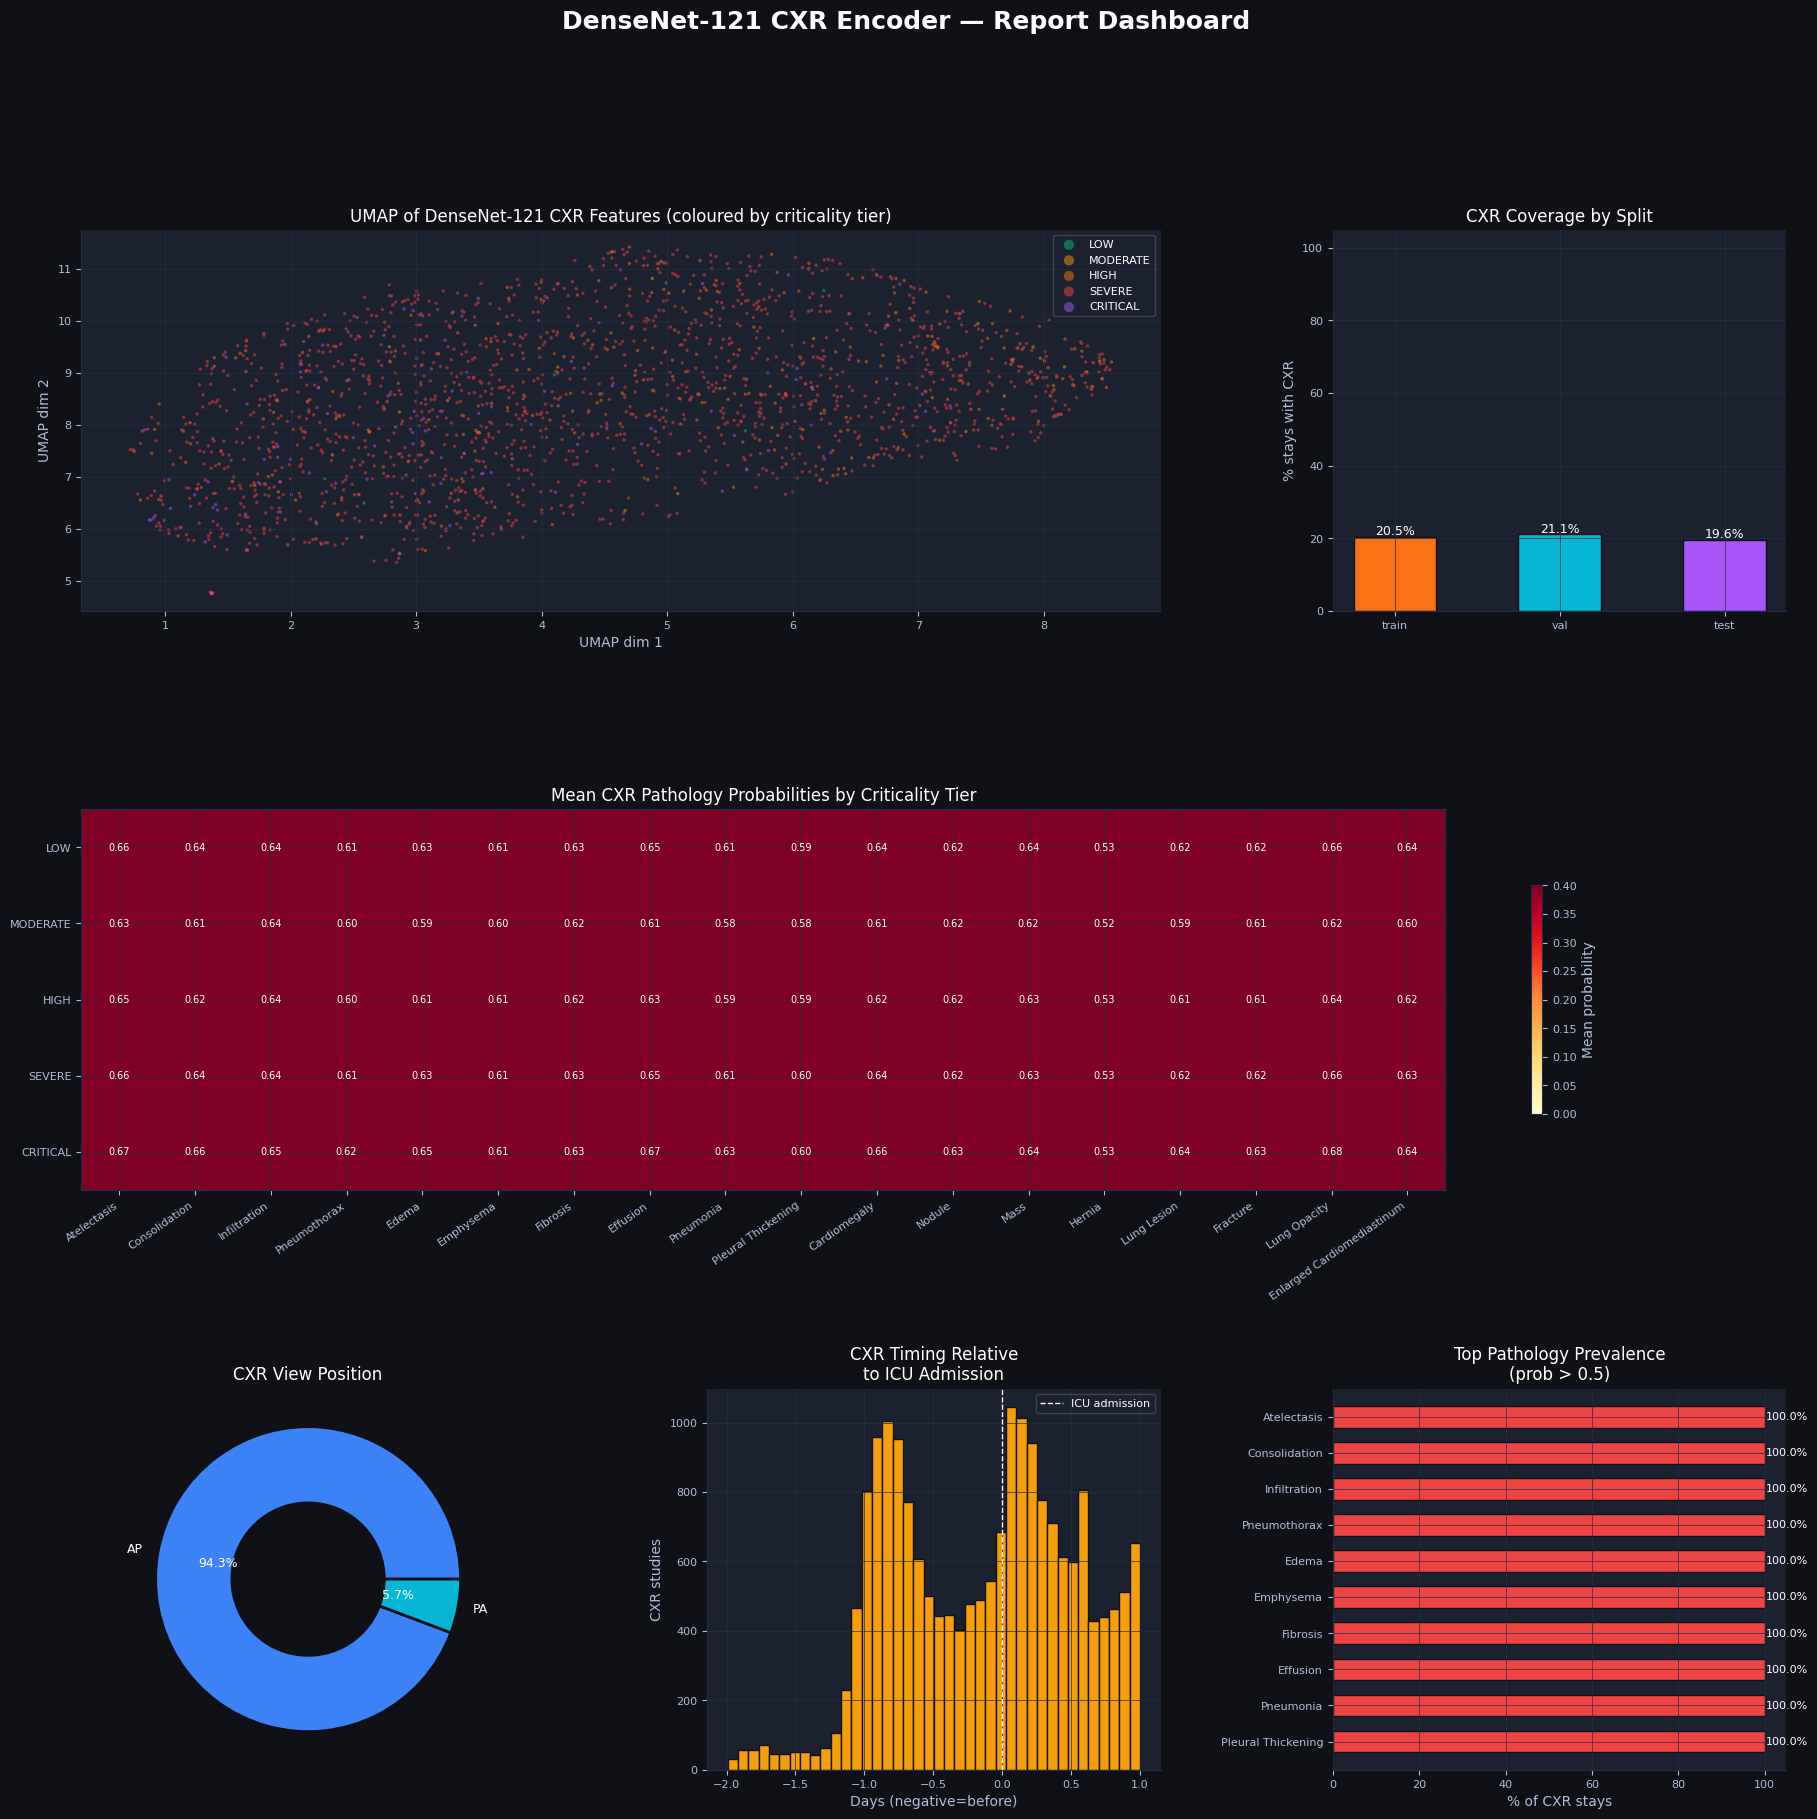

In [35]:
fig2 = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig2.suptitle('DenseNet-121 CXR Encoder — Report Dashboard',
              fontsize=18, fontweight='bold', color=TEXT, y=0.99)
gs2  = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.52, wspace=0.38)

# 1. UMAP of CXR features
ax1 = fig2.add_subplot(gs2[0, :2])
cxr_has     = cxr_full[cxr_full['cxr_available']==1]
sample_cxr  = cxr_has.sample(min(2000, len(cxr_has)), random_state=42)
umap_cxr_2d = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=42).fit_transform(sample_cxr[FEAT_COLS_CXR].values)
tiers_cxr = sample_cxr['stay_id'].map(tier_map).fillna('LOW')
for tier in TIER_ORDER:
    mask = tiers_cxr == tier
    ax1.scatter(umap_cxr_2d[mask,0], umap_cxr_2d[mask,1],
                c=TIER_COLORS[tier], s=6, alpha=0.5, label=tier, edgecolors='none')
ax1.set_title('UMAP of DenseNet-121 CXR Features (coloured by criticality tier)')
ax1.set_xlabel('UMAP dim 1'); ax1.set_ylabel('UMAP dim 2')
ax1.legend(markerscale=3, framealpha=0.2, facecolor=CARD_BG); sp(ax1)

# 2. CXR coverage by split
ax2     = fig2.add_subplot(gs2[0, 2])
cxr_cov = cxr_full.groupby('split')['cxr_available'].agg(['sum','count'])
cxr_cov['pct'] = cxr_cov['sum'] / cxr_cov['count'] * 100
cxr_cov = cxr_cov.reindex(['train','val','test'])
bars2   = ax2.bar(cxr_cov.index, cxr_cov['pct'],
                  color=[PAL['orange'],PAL['teal'],PAL['purple']],
                  edgecolor=DARK_BG, width=0.5)
for bar, val in zip(bars2, cxr_cov['pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'{val:.1f}%', ha='center', fontsize=9, color=TEXT)
ax2.set_title('CXR Coverage by Split'); ax2.set_ylabel('% stays with CXR')
ax2.set_ylim(0, 105); sp(ax2)

# 3. Pathology heatmap by tier
ax3 = fig2.add_subplot(gs2[1, :])
cxr_with_tier = cxr_full.merge(
    scores[['stay_id','criticality_tier']], on='stay_id', how='left')
hmap_data = (
    cxr_with_tier.groupby('criticality_tier')[PROB_COLS_CXR].mean()
).reindex(TIER_ORDER)
clean_labels = [c.replace('cxr_prob_','').replace('_',' ') for c in PROB_COLS_CXR]
im = ax3.imshow(hmap_data.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.4)
ax3.set_xticks(range(len(PROB_COLS_CXR)))
ax3.set_xticklabels(clean_labels, rotation=35, ha='right', fontsize=8)
ax3.set_yticks(range(len(TIER_ORDER))); ax3.set_yticklabels(TIER_ORDER)
for i in range(len(TIER_ORDER)):
    for j in range(len(PROB_COLS_CXR)):
        val = hmap_data.values[i,j]
        if not np.isnan(val):
            ax3.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=7, color='white' if val>0.2 else TEXT)
plt.colorbar(im, ax=ax3, label='Mean probability', shrink=0.6)
ax3.set_title('Mean CXR Pathology Probabilities by Criticality Tier')

# 4. ViewPosition pie
ax4       = fig2.add_subplot(gs2[2, 0])
vp_counts = cxr_filtered['ViewPosition'].value_counts()
ax4.pie(vp_counts, labels=vp_counts.index, autopct='%1.1f%%',
        colors=[PAL['blue'],PAL['teal']],
        wedgeprops=dict(width=0.5, edgecolor=DARK_BG, linewidth=2),
        textprops={'color':TEXT,'fontsize':9})
ax4.set_title('CXR View Position')

# 5. Days from admission to CXR
ax5 = fig2.add_subplot(gs2[2, 1])
cxr_filtered['days_to_cxr'] = (
    (cxr_filtered['study_dt'] - cxr_filtered['intime'])
    .dt.total_seconds() / 86400
)
ax5.hist(cxr_filtered['days_to_cxr'].clip(-2,2), bins=40,
         color=PAL['amber'], edgecolor=DARK_BG)
ax5.axvline(0, color='white', ls='--', lw=1, label='ICU admission')
ax5.set_title('CXR Timing Relative\nto ICU Admission')
ax5.set_xlabel('Days (negative=before)'); ax5.set_ylabel('CXR studies')
ax5.legend(framealpha=0.2, facecolor=CARD_BG); sp(ax5)

# 6. Top pathology prevalence
ax6 = fig2.add_subplot(gs2[2, 2])
path_prev = cxr_full.loc[
    cxr_full['cxr_available']==1, PROB_COLS_CXR
].apply(lambda col: (col > 0.5).mean() * 100).sort_values(ascending=False)
top_path = path_prev.head(10)
bars3    = ax6.barh(range(len(top_path)), top_path.values,
                    color=PAL['red'], edgecolor=DARK_BG, height=0.6)
ax6.set_yticks(range(len(top_path)))
ax6.set_yticklabels(
    [l.replace('cxr_prob_','').replace('_',' ') for l in top_path.index], fontsize=8)
for bar, val in zip(bars3, top_path.values):
    ax6.text(val+0.2, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color=TEXT)
ax6.set_title('Top Pathology Prevalence\n(prob > 0.5)')
ax6.set_xlabel('% of CXR stays'); ax6.invert_yaxis(); sp(ax6)

plt.savefig(CXR_RPT_PNG, dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
log.info('CXR encoder report saved.')

---
# Explainability Layer
> **Text** : ClinicalBERT token attention → plain language risk signals  
> **Image** : Grad-CAM heatmap → anatomical region explanation  
> **Output** : Doctor-readable explanation card per patient

## Explainability A — ClinicalBERT Token Attention

In [36]:
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
MODEL_DIR   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Models')

# Check fusion predictions
preds = pd.read_parquet(PARQUET_DIR / 'icu_fusion_predictions.parquet')
print(f'Fusion predictions : {preds.shape}')
print(f'Stays predicted    : {preds["stay_id"].nunique():,}')
print(f'Columns            : {[c for c in preds.columns if "pred" in c]}')

# Check model files
for f in ['icu_fusion_best.pt','fusion_meta.json',
          'shap_sepsis.npy','shap_mortality.npy']:
    p = MODEL_DIR / f
    status = f'✅ {p.stat().st_size/1e6:.1f}MB' if p.exists() else '❌ missing'
    print(f'{status}  {f}')

Fusion predictions : (94362, 272)
Stays predicted    : 94,362
Columns            : ['pred_sepsis_prob', 'pred_organ_failure_prob', 'pred_mortality_prob', 'pred_criticality', 'pred_criticality_tier', 'pred_crit_prob_LOW', 'pred_crit_prob_MODERATE', 'pred_crit_prob_HIGH', 'pred_crit_prob_SEVERE', 'pred_crit_prob_CRITICAL']
✅ 12.7MB  icu_fusion_best.pt
✅ 0.0MB  fusion_meta.json
✅ 1.5MB  shap_sepsis.npy
✅ 1.5MB  shap_mortality.npy


In [37]:
# ── Reload notes_clean from Drive
from pathlib import Path
import pandas as pd

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
TEXT_EMB_OUT = PARQUET_DIR / 'icu_text_embeddings.parquet'

# Load text embeddings which contains the text
stay_text_emb = pd.read_parquet(TEXT_EMB_OUT)

# Check if text column exists
text_cols = [c for c in stay_text_emb.columns if 'text' in c.lower()]
log.info('Text columns available: %s', text_cols)

if 'text' in stay_text_emb.columns:
    notes_clean = stay_text_emb[['stay_id', 'text']].dropna(subset=['text'])
    log.info('notes_clean rebuilt: %d rows', len(notes_clean))
else:
    # Try loading from encoder features
    enc_df = pd.read_parquet(PARQUET_DIR / 'icu_encoder_features.parquet')
    text_cols_enc = [c for c in enc_df.columns if 'text' in c.lower()]
    log.info('Encoder text cols: %s', text_cols_enc)

    # Load raw notes from BigQuery as fallback
    import pandas_gbq
    notes_clean = pandas_gbq.read_gbq("""
        SELECT n.subject_id, n.hadm_id, n.text,
               i.stay_id
        FROM physionet-data.mimiciv_note.discharge n
        JOIN physionet-data.mimiciv_hosp.admissions a
          ON n.subject_id = a.subject_id
          AND n.hadm_id   = a.hadm_id
        JOIN physionet-data.mimiciv_icu.icustays i
          ON a.hadm_id = i.hadm_id
        LIMIT 500
    """, project_id='icuaiassistanttextencoder', location='US')
    log.info('notes_clean from BQ: %s', notes_clean.shape)

# ── Also rebuild clean_note_text if missing
try:
    _ = clean_note_text
except NameError:
    import re
    def clean_note_text(text: str) -> str:
        text = re.sub(r'\[\*\*.*?\*\*\]', '', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    log.info('clean_note_text rebuilt')

# ── Also rebuild tokenizer and MAX_TOKENS if missing
try:
    _ = tokenizer
except NameError:
    from transformers import AutoTokenizer
    tokenizer  = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')
    MAX_TOKENS = 512
    log.info('tokenizer rebuilt')

# ── Test
result = explain_note_text(notes_clean['text'].iloc[0])
print('='*60)
print('CLINICAL NOTE EXPLANATION')
print('='*60)
print(f'\nSUMMARY: {result["summary"]}')
if result['high_risk_signals']:
    print('\nHIGH-RISK SIGNALS:')
    for s in result['high_risk_signals']:
        print(f'  [{"#"*int(s["attention"]*20):<20}] {s["attention"]:.3f}  '
              f'"{s["word"]}" = {s["plain"]}')

GenericGBQException: Reason: 403 POST https://bigquery.googleapis.com/bigquery/v2/projects/icuaiassistanttextencoder/queries?prettyPrint=false: Access Denied: Table physionet-data:mimiciv_hosp.admissions: User does not have permission to query table physionet-data:mimiciv_hosp.admissions, or perhaps it does not exist.

In [ ]:
import matplotlib.patches as mpatches, re
from transformers import AutoTokenizer, AutoModel

# ── Reload bert_model with eager attention (required for output_attentions=True)
log.info('Reloading ClinicalBERT with eager attention for explainability...')
bert_model_explain = AutoModel.from_pretrained(
    'emilyalsentzer/Bio_ClinicalBERT',
    output_hidden_states=True,
    attn_implementation='eager'   # ← fixes the sdpa issue
)
bert_model_explain.eval().to(DEVICE)
log.info('ClinicalBERT (eager) loaded on %s', DEVICE)

CLINICAL_PLAIN = {
    'tachycardia':'fast heart rate','bradycardia':'slow heart rate',
    'hypotension':'low blood pressure','hypertension':'high blood pressure',
    'tachypnea':'rapid breathing','hypoxia':'low blood oxygen',
    'febrile':'fever','afebrile':'no fever',
    'aki':'acute kidney injury','arf':'acute respiratory failure',
    'ards':'severe lung failure','sepsis':'life-threatening infection response',
    'septic shock':'infection causing dangerously low BP',
    'bacteremia':'bacteria in the bloodstream','pneumonia':'lung infection',
    'intubated':'breathing tube inserted','intubation':'placement of breathing tube',
    'ventilator':'breathing machine','mechanical ventilation':'breathing machine support',
    'dialysis':'kidney replacement therapy','creatinine':'kidney stress marker',
    'bilirubin':'liver stress marker','lactate':'tissue oxygen deprivation marker',
    'troponin':'heart muscle injury marker','platelets':'blood clotting cells',
    'wbc':'white blood cell count (infection marker)',
    'altered mental status':'confusion / reduced consciousness',
    'gcs':'consciousness score','pressors':'blood pressure-raising medications',
    'vasopressors':'medications to raise blood pressure',
    'norepinephrine':'blood pressure medication (norepinephrine)',
    'dopamine':'blood pressure medication (dopamine)',
    'dobutamine':'heart support medication','heparin':'blood-thinning medication',
    'dnr':'do-not-resuscitate order','comfort measures':'palliative / end-of-life care',
    'transfer':'moved between care units','icu':'intensive care unit',
    'copd':'chronic lung disease','chf':'chronic heart failure',
    'cirrhosis':'chronic liver scarring','malignancy':'cancer',
    'immunocompromised':'weakened immune system','diabetes':'blood sugar disorder',
    'coagulopathy':'blood clotting disorder',
}

RISK_TERMS = {
    'high_risk': ['sepsis','septic shock','ards','intubated','vasopressors',
                  'norepinephrine','aki','arf','altered mental status','dnr',
                  'comfort measures','multi-organ','bacteremia','lactate','pressors'],
    'moderate_risk': ['pneumonia','hypotension','tachycardia','hypoxia','ventilator',
                      'dialysis','creatinine','troponin','gcs','transfer'],
    'protective': ['afebrile','stable','improved','extubated','tolerating',
                   'ambulating','discharged','weaned'],
}


@torch.no_grad()
def get_token_attention(text: str):
    text_clean = clean_note_text(text)[:2000]
    encoded    = tokenizer(text_clean, return_tensors='pt',
                           truncation=True, max_length=MAX_TOKENS)
    encoded    = {k: v.to(DEVICE) for k, v in encoded.items()}

    # ── Use eager model for attention extraction
    outputs    = bert_model_explain(**encoded, output_attentions=True)

    if outputs.attentions is None:
        raise ValueError('Attentions are None — check attn_implementation=eager')

    last_attn  = outputs.attentions[-1][0]   # (n_heads, seq_len, seq_len)
    token_attn = last_attn.mean(dim=0).mean(dim=0).cpu().numpy()
    tokens     = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0].cpu())
    return tokens, token_attn


def merge_wordpieces(tokens, weights):
    words, wts, cur_w, cur_wt = [], [], '', 0.0
    for tok, w in zip(tokens, weights):
        if tok in ('[CLS]','[SEP]','[PAD]'): continue
        if tok.startswith('##'): cur_w += tok[2:]; cur_wt = max(cur_wt, w)
        else:
            if cur_w: words.append(cur_w); wts.append(cur_wt)
            cur_w, cur_wt = tok, w
    if cur_w: words.append(cur_w); wts.append(cur_wt)
    return words, np.array(wts)


def classify_word_risk(word):
    w = word.lower()
    for cat, terms in RISK_TERMS.items():
        if any(t in w or w in t for t in terms): return cat
    return 'neutral'


def plain_name(word):
    w = word.lower()
    for term, plain in CLINICAL_PLAIN.items():
        if term in w: return plain
    return word


def explain_note_text(text: str, top_n: int = 8) -> dict:
    tokens, attn = get_token_attention(text)
    words, weights = merge_wordpieces(tokens, attn)
    if weights.max() > 0: weights = weights / weights.max()

    STOPWORDS = {'the','a','an','is','was','were','of','in','to','and',
                 'or','with','for','on','at','by','from','that','this',
                 'he','she','his','her','patient','pt','dr','mr','ms'}
    eligible  = [(w,s) for w,s in zip(words,weights)
                 if len(w)>2 and w.lower() not in STOPWORDS]
    top_words = sorted(eligible, key=lambda x: x[1], reverse=True)[:top_n]

    high_risk, protective, neutral = [], [], []
    for word, score in top_words:
        entry = {'word':word,'plain':plain_name(word),'attention':round(float(score),3)}
        cat   = classify_word_risk(word)
        if   cat == 'high_risk':  high_risk.append(entry)
        elif cat == 'protective': protective.append(entry)
        else:                     neutral.append(entry)

    parts = []
    if high_risk:  parts.append('Concerning findings: ' +
                                 ', '.join(s['plain'] for s in high_risk[:3]) + '.')
    if protective: parts.append('Reassuring signs: ' +
                                 ', '.join(s['plain'] for s in protective[:2]) + '.')
    if not parts:  parts.append('No strongly risk-indicating terms identified.')

    return {'summary':' '.join(parts),
            'high_risk_signals':high_risk,'protective_signals':protective,
            'other_signals':neutral,'top_words':top_words,
            'all_words':words,'all_weights':weights}


# Demo
result = explain_note_text(notes_clean['text'].iloc[0])
print('='*60)
print('CLINICAL NOTE EXPLANATION')
print('='*60)
print(f'\nSUMMARY: {result["summary"]}')
if result['high_risk_signals']:
    print('\nHIGH-RISK SIGNALS:')
    for s in result['high_risk_signals']:
        print(f'  [{"#"*int(s["attention"]*20):<20}] {s["attention"]:.3f}  "{s["word"]}" = {s["plain"]}')
if result['protective_signals']:
    print('\nREASSURING SIGNALS:')
    for s in result['protective_signals']:
        print(f'  [{"#"*int(s["attention"]*20):<20}] {s["attention"]:.3f}  "{s["word"]}" = {s["plain"]}')

### Visualise — Token Attention Heatmap

In [ ]:
def plot_text_attention(result: dict, title: str = 'Clinical Note Attention') -> None:
    words, weights = result['all_words'][:60], result['all_weights'][:60]
    fig, ax = plt.subplots(figsize=(20, 5), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off'); ax.set_title(title, color=TEXT, fontsize=12, pad=10)

    x, y = 0.01, 0.85
    for word, weight in zip(words, weights):
        cat = classify_word_risk(word)
        if   cat == 'high_risk':     bg=(0.86,0.15+weight*0.2,0.15+weight*0.1); fc='white'
        elif cat == 'protective':    bg=(0.1,0.5+weight*0.3,0.2); fc='white'
        elif cat == 'moderate_risk': bg=(0.8,0.5+weight*0.2,0.1); fc='white'
        else:
            i2 = 0.2+weight*0.5; bg=(i2,i2,i2+0.1)
            fc = 'white' if weight>0.4 else '#94A3B8'
        ww = len(word)*0.013+0.015
        if x+ww > 0.99: x=0.01; y-=0.18
        if y < 0.05: break
        ax.add_patch(plt.Rectangle((x,y-0.08),ww,0.12,facecolor=bg,
                                    edgecolor='none',transform=ax.transAxes,clip_on=False))
        ax.text(x+ww/2,y-0.02,word,color=fc,fontsize=8,fontweight='bold',
                ha='center',va='center',transform=ax.transAxes)
        x += ww+0.005

    ax.legend(handles=[
        mpatches.Patch(color='#DC2626',label='High-risk signal'),
        mpatches.Patch(color='#EA580C',label='Moderate-risk signal'),
        mpatches.Patch(color='#16A34A',label='Protective / reassuring'),
        mpatches.Patch(color='#475569',label='Neutral / low attention'),
    ], loc='lower right', framealpha=0.3, facecolor=CARD_BG,
               labelcolor=TEXT, fontsize=8)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_text_attention_demo.png',
                dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()


plot_text_attention(result, title='Clinical Note — Token Attention Heatmap')

## Explainability B — Grad-CAM for Chest X-Ray

In [ ]:
import torch.nn.functional as F

CXR_REGION_MAP = {
    (0,0):('Upper left lung','Left upper lobe — pneumonia, mass'),
    (0,1):('Upper central','Trachea / upper mediastinum — widening'),
    (0,2):('Upper right lung','Right upper lobe — TB, pneumonia, mass'),
    (1,0):('Left mid lung','Left hilum — consolidation'),
    (1,1):('Heart / mediastinum','Cardiac silhouette — enlarged = heart failure'),
    (1,2):('Right mid lung','Right hilum — consolidation, effusion'),
    (2,0):('Left base','Left lower lobe — fluid, atelectasis'),
    (2,1):('Lower central','Lower mediastinum / diaphragm'),
    (2,2):('Right base','Right lower lobe — most common pneumonia site'),
}
PATHOLOGY_PLAIN = {
    'Consolidation':'lung fluid/pus (pneumonia)',
    'Pleural Effusion':'fluid around the lung',
    'Atelectasis':'collapsed lung area',
    'Pneumothorax':'air leak collapsing the lung',
    'Cardiomegaly':'enlarged heart shadow',
    'Edema':'lung fluid (heart failure)',
    'Lung Opacity':'haziness — infection or fluid',
    'Fracture':'rib or bone fracture',
    'Support Devices':'tubes, lines, or devices',
    'No Finding':'no obvious abnormality',
    'Enlarged Cardiomediastinum':'widened central chest structures',
}


class GradCAMExtractor:
    def __init__(self, model):
        self.model = model; self.gradients = None; self.activations = None
        t = model.features.denseblock4
        t.register_forward_hook(lambda m,i,o: setattr(self,'activations',o.detach()))
        t.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0].detach()))

    def generate_cam(self, img_tensor, target_idx):
        self.model.zero_grad()
        img_tensor.requires_grad_(True)
        self.model(img_tensor)[0, target_idx].backward()
        weights  = self.gradients.mean(dim=[2,3], keepdim=True)
        cam      = F.relu((weights * self.activations).sum(dim=1,keepdim=True))
        cam      = F.interpolate(cam.squeeze().unsqueeze(0).unsqueeze(0).float(),
                                  size=(224,224), mode='bilinear',
                                  align_corners=False).squeeze().cpu().numpy()
        if cam.max() > 0: cam /= cam.max()
        return cam


def get_top_cam_regions(cam, threshold=0.5):
    h, w = cam.shape; gh, gw = h//3, w//3
    regions = []
    for r in range(3):
        for c in range(3):
            m = float(cam[r*gh:(r+1)*gh, c*gw:(c+1)*gw].mean())
            if m >= threshold:
                name, meaning = CXR_REGION_MAP.get((r,c),('Unknown','Unknown'))
                regions.append({'region':name,'meaning':meaning,
                                'activation':round(m,3),'grid_pos':(r,c)})
    return sorted(regions, key=lambda x: x['activation'], reverse=True)


def explain_cxr(record_path: str, pathology_probs: dict,
                target_label: str = 'Consolidation') -> None:
    img_arr = load_cxr_wget(record_path)
    if img_arr is None:
        print(f'Could not load: {record_path}'); return

    img_proc   = xrv.datasets.XRayResizer(224)(xrv.datasets.XRayCenterCrop()(img_arr))
    img_tensor = torch.tensor(img_proc, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    label_list = [str(l) for l in cxr_model.pathologies]
    if target_label not in label_list: target_label = label_list[0]
    cam         = GradCAMExtractor(cxr_model).generate_cam(
        img_tensor, label_list.index(target_label))
    top_regions = get_top_cam_regions(cam, threshold=0.3)

    fig    = plt.figure(figsize=(20, 8), facecolor=DARK_BG)
    gs_cxr = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1,1,1.2], wspace=0.08)

    ax_orig = fig.add_subplot(gs_cxr[0])
    ax_orig.imshow(img_proc[0], cmap='gray', aspect='auto')
    ax_orig.set_title('Original CXR', color=TEXT, fontsize=11); ax_orig.axis('off')

    ax_cam = fig.add_subplot(gs_cxr[1])
    ax_cam.imshow(img_proc[0], cmap='gray', aspect='auto')
    ax_cam.imshow(cam, cmap='jet', alpha=0.45, aspect='auto')
    ax_cam.set_title(f'Grad-CAM: "{target_label}"', color=TEXT, fontsize=11)
    ax_cam.axis('off')
    for r in top_regions[:3]:
        row, col = r['grid_pos']
        ax_cam.add_patch(plt.Rectangle((col*224/3,row*224/3),224/3,224/3,
                                        fill=False,edgecolor='yellow',
                                        linewidth=1.5,linestyle='--'))
        ax_cam.text(col*224/3+4,row*224/3+14,f'{r["activation"]:.2f}',
                    color='yellow',fontsize=7,fontweight='bold')

    ax_txt = fig.add_subplot(gs_cxr[2])
    ax_txt.set_facecolor(CARD_BG); ax_txt.axis('off')
    top_probs = sorted(pathology_probs.items(), key=lambda x: x[1], reverse=True)[:6]
    lines = [('WHAT THE MODEL DETECTED','#F1F5F9',13,True),('','',9,False)]
    for lbl, prob in top_probs:
        pct   = prob*100
        color = '#DC2626' if pct>50 else '#EA580C' if pct>25 else '#94A3B8'
        lines += [(f'{lbl}: {pct:.0f}%',color,10,True),
                  (f'  = {PATHOLOGY_PLAIN.get(lbl,lbl)}','#94A3B8',9,False)]
    lines += [('','',9,False),('WHERE THE MODEL LOOKED','#F1F5F9',13,True),('','',9,False)]
    for r in top_regions[:4]:
        pct   = r['activation']*100
        color = '#DC2626' if pct>60 else '#EA580C' if pct>40 else '#CA8A04'
        lines += [(f'{r["region"]} ({pct:.0f}% focus)',color,10,True),
                  (f'  {r["meaning"]}','#94A3B8',8,False)]
    y_pos = 0.97
    for txt, color, size, bold in lines:
        if txt:
            ax_txt.text(0.03,y_pos,txt,color=color,fontsize=size,
                        fontweight='bold' if bold else 'normal',
                        transform=ax_txt.transAxes,va='top')
        y_pos -= 0.062 if size>=10 else 0.05
        if y_pos < 0.02: break

    plt.savefig(f'/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/'
                f'icu_cxr_gradcam_{target_label.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print('\n' + '='*60)
    print('CHEST X-RAY EXPLANATION')
    print('='*60)
    for r in top_regions[:4]:
        print(f'  [{r["activation"]*100:.0f}%] {r["region"]}: {r["meaning"]}')
    for lbl, prob in top_probs:
        flag = ' <-- HIGH' if prob>0.5 else ''
        print(f'  {prob*100:5.1f}%  {lbl}: {PATHOLOGY_PLAIN.get(lbl,lbl)}{flag}')


# Demo
if len(cxr_filtered) > 0:
    demo_row     = cxr_filtered.iloc[0]
    demo_cxr_row = cxr_emb_df[cxr_emb_df['stay_id'] == demo_row['stay_id']]
    if len(demo_cxr_row) > 0:
        prob_dict = {
            col.replace('cxr_prob_','').replace('_',' '): float(demo_cxr_row[col].iloc[0])
            for col in PROB_COLS_CXR
        }
        top_label = max(prob_dict, key=prob_dict.get)
        explain_cxr(demo_row['path'], prob_dict, target_label=top_label)

## Explainability C — Combined Patient Explanation Card

In [ ]:
def explain_patient(stay_id: int) -> None:
    print('\n' + '='*65)
    print(f'  PATIENT EXPLANATION CARD — Stay ID: {stay_id}')
    print('='*65)

    pat = cohort[cohort['stay_id'] == stay_id]
    if len(pat) > 0:
        static_row = static[static['stay_id'] == stay_id].iloc[0]
        print(f'\nPatient overview:')
        print(f'  Age          : {static_row["age_icu"]} years')
        print(f'  Gender       : {"Male" if static_row["gender"]=="M" else "Female"}')
        print(f'  Admission    : {"Elective" if static_row["is_elective"] else "Emergency"}')
        print(f'  Chronic dx   : {"Yes" if static_row["has_chronic"] else "None recorded"}')

    scores_df = pd.read_parquet(BASE / 'icu_risk_scores.parquet')
    score_row = scores_df[scores_df['stay_id'] == stay_id]
    if len(score_row) > 0:
        sr = score_row.iloc[0]
        tier_label = {'LOW':'(stable)','MODERATE':'(watch)','HIGH':'(elevated)',
                      'SEVERE':'(!! urgent)','CRITICAL':'(!!! critical)'}
        print(f'\nRisk assessment:')
        print(f'  Criticality  : {sr["criticality_tier"]} {tier_label.get(sr["criticality_tier"],"")}')
        print(f'  Mortality    : {sr["apache2_pred_mortality"]*100:.1f}% (APACHE II)')
        print(f'  Sepsis alert : {"YES — act now" if sr["sepsis_alert"] else "No"}')
        print(f'  Organ failure: {"Yes" if sr["organ_dysfunction"] else "No"} '
              f'({int(sr["organ_failure_count"])} organ(s))')

    hadm_id = cohort.loc[cohort['stay_id']==stay_id, 'hadm_id']
    if len(hadm_id) > 0:
        stay_notes = notes_clean[notes_clean['hadm_id'] == int(hadm_id.iloc[0])]
        if len(stay_notes) > 0:
            text_exp = explain_note_text(stay_notes['text'].iloc[0])
            print(f'\nClinical note analysis ({len(stay_notes)} note(s)):')
            print(f'  {text_exp["summary"]}')
            if text_exp['high_risk_signals']:
                print('  Risk signals : ' +
                      ', '.join(s['plain'] for s in text_exp['high_risk_signals'][:4]))
            if text_exp['protective_signals']:
                print('  Reassuring   : ' +
                      ', '.join(s['plain'] for s in text_exp['protective_signals'][:3]))
        else:
            print('\nClinical note: not available for this stay')

    cxr_row = cxr_filtered[cxr_filtered['stay_id'] == stay_id]
    if len(cxr_row) > 0:
        cxr_emb_row = cxr_emb_df[cxr_emb_df['stay_id'] == stay_id]
        if len(cxr_emb_row) > 0:
            prob_dict    = {
                col.replace('cxr_prob_','').replace('_',' '): float(cxr_emb_row[col].iloc[0])
                for col in PROB_COLS_CXR
            }
            top_findings = [(k,v) for k,v in
                            sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)
                            if v > 0.2][:4]
            print(f'\nChest X-ray findings:')
            for label, prob in top_findings:
                flag = ' <-- significant' if prob>0.5 else ''
                print(f'  {prob*100:5.1f}%  {label}: {PATHOLOGY_PLAIN.get(label,label)}{flag}')
    else:
        print('\nChest X-ray: not available within admission window')
    print('\n' + '='*65)


test_stays = cohort[cohort['split']=='test']['stay_id'].values
if len(test_stays) > 0:
    explain_patient(test_stays[0])
    explain_patient(test_stays[1])

## Step 12 — Output Summary & Next Steps

In [ ]:
print('=== MULTIMODAL ENCODER OUTPUTS ===')
for path in [TEXT_EMB_OUT, CXR_EMB_OUT, TEXT_RPT_PNG, CXR_RPT_PNG,
             MODEL_DIR / 'embedding_meta.json']:
    p      = Path(path)
    exists = p.exists()
    size   = p.stat().st_size / 1e6 if exists else 0
    print(f'  {"OK" if exists else "MISSING":6s} | {size:6.1f} MB | {p.name}')

print(f'\n=== COVERAGE SUMMARY ===')
print(f'  Total stays         : {len(cohort):,}')
print(f'  With text note      : {stay_text_emb["text_available"].sum():,}'
      f' ({stay_text_emb["text_available"].mean()*100:.1f}%)')
print(f'  With CXR image      : {cxr_full["cxr_available"].sum():,}'
      f' ({cxr_full["cxr_available"].mean()*100:.1f}%)')
print(f'  With both modalities: '
      f'{(stay_text_emb["text_available"].values & cxr_full["cxr_available"].values).sum():,}')
print(f'\n=== EMBEDDING DIMENSIONS ===')
print(f'  ClinicalBERT text  : 768 dims per stay')
print(f'  DenseNet CXR feats : {len(FEAT_COLS_CXR)} dims per stay')
print(f'  DenseNet CXR probs : {len(PROB_COLS_CXR)} pathologies per stay')
print(f'\n=== READY FOR FUSION LAYER ===')
print('  Next: ICUFusionLayer.ipynb')
print('  Inputs: icu_text_embeddings.parquet + icu_cxr_embeddings.parquet')

To find Stay ID with CXR Image

In [ ]:
import pandas as pd
from pathlib import Path

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
CXR_CACHE   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/cxr_cache')

# Load predictions to get risk info
preds   = pd.read_parquet(PARQUET_DIR / 'icu_fusion_predictions.parquet')
cxr_emb = pd.read_parquet(PARQUET_DIR / 'icu_cxr_embeddings.parquet',
                           columns=['stay_id', 'cxr_available'])

# Get cached image filenames
jpg_files = {f.stem: f.name for f in CXR_CACHE.glob('*.jpg')}
print(f'Images in cache: {len(jpg_files):,}')

# Find stays with CXR available
cxr_stays = cxr_emb[cxr_emb['cxr_available'] == 1]['stay_id'].tolist()
print(f'Stays with CXR  : {len(cxr_stays):,}')

# Merge with predictions to find interesting ones
cxr_preds = preds[preds['stay_id'].isin(cxr_stays)][
    ['stay_id', 'pred_sepsis_prob', 'pred_mortality_prob',
     'pred_criticality_tier']
].copy()

# Show top 10 most critical with CXR
top = cxr_preds.sort_values('pred_mortality_prob', ascending=False).head(10)
print('\nTop 10 CRITICAL stays WITH CXR image:')
print(top[['stay_id','pred_criticality_tier',
           'pred_sepsis_prob','pred_mortality_prob']].to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PARQUET_DIR = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
CXR_CACHE   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/cxr_cache')

# ── Build path map: stay_id → jpg filename
cxr_emb = pd.read_parquet(PARQUET_DIR / 'icu_cxr_embeddings.parquet',
                           columns=['stay_id', 'cxr_available'])

# Load the split CSV to get dicom_id → path mapping
import gzip, io, requests
from requests.auth import HTTPBasicAuth

# Load split CSV (already downloaded before)
SPLIT_CACHE = Path('/content/mimic_cxr_split.csv.gz')
META_CACHE  = Path('/content/mimic_cxr_metadata.csv.gz')

if not SPLIT_CACHE.exists():
    print('Downloading split CSV...')
    r = requests.get(
        'https://physionet.org/files/mimic-cxr-jpg/2.0.0/mimic-cxr-2.0.0-split.csv.gz',
        auth=HTTPBasicAuth(PHYSIONET_USER, PHYSIONET_PASS), timeout=60
    )
    SPLIT_CACHE.write_bytes(r.content)

split_df = pd.read_csv(SPLIT_CACHE)
print(f'Split CSV: {split_df.shape} | cols: {split_df.columns.tolist()}')

# Load CXR filtered (has stay_id + dicom_id + path)
cxr_path_map_file = PARQUET_DIR / 'icu_cxr_path_map.parquet'
if cxr_path_map_file.exists():
    cxr_pm = pd.read_parquet(cxr_path_map_file)
    print(f'Existing path map: {cxr_pm.shape}')
    print(f'Columns: {cxr_pm.columns.tolist()}')
    print(cxr_pm.head(3).to_string())

In [ ]:
# ── Build stay_id → filename mapping from cxr_filtered
# cxr_filtered has: stay_id, path (e.g. files/p11/.../xxx.jpg)
try:
    cxr_filtered_df = pd.read_parquet(PARQUET_DIR / 'icu_cxr_path_map.parquet')
except:
    # Rebuild from encoder features if available
    print('Rebuilding path map...')

# Get all jpg files in cache
jpg_files = {f.name: f for f in CXR_CACHE.glob('*.jpg')}
print(f'JPG files in cache: {len(jpg_files):,}')

# The filename is the last part of the path
# e.g. path = "files/p11/p11724340/s55646923/98ba6728-xxx.jpg"
# filename = "98ba6728-xxx.jpg"

# Load cxr_emb with path column
cxr_emb_full = pd.read_parquet(PARQUET_DIR / 'icu_cxr_embeddings.parquet')
path_cols = [c for c in cxr_emb_full.columns if 'path' in c.lower() or 'dicom' in c.lower() or 'file' in c.lower()]
print(f'Path-related columns: {path_cols}')
print(cxr_emb_full[['stay_id'] + path_cols[:5]].head(3).to_string() if path_cols else 'No path cols')